# Tarea 1 — Árboles de Decisión: **ID3**



## ¿Qué es un Árbol de Decisión?

Modelo de **aprendizaje supervisado** con estructura jerárquica de nodos: cada **nodo interno** hace
una *pregunta* sobre un atributo, cada **rama** es una respuesta, y cada **hoja** es la predicción.
El entrenamiento elige en cada nodo el atributo que mejor **separa** los datos según un criterio de
pureza. Los tres algoritmos de la familia (Grupo B):

| Algoritmo | Año | Autor | Criterio | División | Objetivo |
|-----------|-----|-------|----------|----------|----------|
| **ID3**   | 1986 | Quinlan | Ganancia de Información (Entropía) | Multi-vía | Categórico |
| **CART**  | 1984 | Breiman et al. | Índice Gini / MSE | Binaria | Categórico o numérico |
| **CHAID** | 1980 | Kass | Chi-cuadrado (χ²) | Multi-vía (con fusión) | Categórico |


## Ficha técnica

### Descripción
**ID3 (Iterative Dichotomiser 3)** es uno de los primeros algoritmos para construir árboles de
decisión. Construye el árbol de forma **recursiva y voraz (greedy)**, seleccionando en cada nodo el
atributo con la **mayor Ganancia de Información** (mayor reducción de entropía) y generando una rama
por cada valor del atributo categórico elegido.

### Tipo de Modelo
- **Método de aprendizaje:** Supervisado (clasificación)
- **Por Parámetros:** No paramétrico
- **Datos de aprendizaje:** Offline / Batch
- **Resultado del entrenamiento:** Basado en Modelo (árbol de reglas legibles)

### Algoritmo de Entrenamiento
Recursión voraz *top-down* guiada por **Ganancia de Información** basada en **Entropía de Shannon**:

$$Entropía(S) = -\sum_{i=1}^{c} p_i \log_2 p_i \qquad
Ganancia(S, A) = Entropía(S) - \sum_{v \in valores(A)} \frac{|S_v|}{|S|}\, Entropía(S_v)$$

### Supuestos y Restricciones
- Atributos **categóricos** (las continuas requieren discretización).
- **No maneja valores faltantes** de forma nativa.
- Tiende al **sobreajuste** (crece hasta clasificar perfecto; sin poda).
- **Sesgo** hacia atributos con muchos valores distintos.
- Solo **clasificación**, no regresión.


## 1. Publicación que propuso el algoritmo
> **Quinlan, J. R. (1986). *Induction of Decision Trees*. Machine Learning, 1(1), 81–106.**

Ross Quinlan lo formalizó en 1986; es el precursor directo de **C4.5** y **C5.0**.

```bibtex
@article{quinlan1986induction,
  title={Induction of decision trees},
  author={Quinlan, J. Ross},
  journal={Machine learning}, volume={1}, number={1},
  pages={81--106}, year={1986}, publisher={Springer}
}
```
**APA:** Quinlan, J. R. (1986). Induction of decision trees. *Machine Learning, 1*(1), 81–106.

## 2. Cómo funciona (paso a paso)
1. Calcular la **entropía** del conjunto actual `S`.
2. Calcular la **Ganancia de Información** de cada atributo.
3. Elegir el atributo con **mayor ganancia** como nodo de decisión.
4. Crear una **rama por cada valor** y repartir los ejemplos.
5. **Repetir recursivamente** hasta clase pura, sin atributos, o subconjunto vacío (clase mayoritaria).

## 3. Tipos de entrada
- Atributos **categóricos / nominales**; objetivo **categórico**.
- Variables numéricas → **discretizadas** (binning) antes de usarlas.
- **No** admite valores faltantes de forma nativa.

## 4. Casos de uso
- Sistemas de **reglas explicables** (diagnóstico, crédito).
- Datos **puramente categóricos** (encuestas, formularios).
- Docencia: ejemplo canónico de entropía y ganancia de información.

## 5. Source Code — Ejemplo didáctico (PlayTennis)
Implementamos ID3 **desde cero** (sin librerías de ML) para mostrar con transparencia el cálculo de
entropía y ganancia de información sobre el dataset clásico **PlayTennis** de Quinlan.


In [ ]:
import warnings; warnings.filterwarnings("ignore")
import pandas as pd
import matplotlib.pyplot as plt

# ------- Dataset clásico "PlayTennis" (Quinlan) -------
data = {
    "Outlook":   ["Sunny","Sunny","Overcast","Rain","Rain","Rain","Overcast",
                  "Sunny","Sunny","Rain","Sunny","Overcast","Overcast","Rain"],
    "Temp":      ["Hot","Hot","Hot","Mild","Cool","Cool","Cool",
                  "Mild","Cool","Mild","Mild","Mild","Hot","Mild"],
    "Humidity":  ["High","High","High","High","Normal","Normal","Normal",
                  "High","Normal","Normal","Normal","High","Normal","High"],
    "Wind":      ["Weak","Strong","Weak","Weak","Weak","Strong","Strong",
                  "Weak","Weak","Weak","Strong","Strong","Weak","Strong"],
    "PlayTennis":["No","No","Yes","Yes","Yes","No","Yes",
                  "No","Yes","Yes","Yes","Yes","Yes","No"],
}
df_id3 = pd.DataFrame(data)
df_id3


,Outlook,Temp,Humidity,Wind,PlayTennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [ ]:
# ------- Implementación de ID3 desde cero -------
import math
from collections import Counter

def entropy(labels):
    total = len(labels); counts = Counter(labels)
    return -sum((c/total) * math.log2(c/total) for c in counts.values())

def info_gain(df, attr, target):
    total = len(df); base = entropy(df[target].tolist()); weighted = 0.0
    for val, subset in df.groupby(attr):
        weighted += (len(subset)/total) * entropy(subset[target].tolist())
    return base - weighted

def id3(df, target, attributes, depth=0, max_depth=None, verbose=True):
    labels = df[target].tolist()
    if len(set(labels)) == 1:                                   # clase pura -> hoja
        return labels[0]
    if not attributes or (max_depth is not None and depth >= max_depth):
        return Counter(labels).most_common(1)[0][0]             # -> clase mayoritaria
    gains = {a: info_gain(df, a, target) for a in attributes}
    best = max(gains, key=gains.get)
    if verbose:
        print("  " * depth + f"[Nivel {depth}] " +
              ", ".join(f"{a}={g:.3f}" for a, g in gains.items()) + f"  -> elige '{best}'")
    tree = {best: {}}
    remaining = [a for a in attributes if a != best]
    for val, subset in df.groupby(best):
        tree[best][val] = id3(subset, target, remaining, depth + 1, max_depth, verbose)
    return tree

target = "PlayTennis"; attrs = ["Outlook", "Temp", "Humidity", "Wind"]
print(f"Entropía inicial: {entropy(df_id3[target].tolist()):.3f}\n")
print("Construcción del árbol (ganancias por nivel):")
arbol_id3 = id3(df_id3, target, attrs)


Entropía inicial: 0.940

Construcción del árbol (ganancias por nivel):
[Nivel 0] Outlook=0.247, Temp=0.029, Humidity=0.152, Wind=0.048  -> elige 'Outlook'
  [Nivel 1] Temp=0.020, Humidity=0.020, Wind=0.971  -> elige 'Wind'
  [Nivel 1] Temp=0.571, Humidity=0.971, Wind=0.020  -> elige 'Humidity'


In [ ]:
# ------- Árbol en texto y predicción -------
def print_tree(tree, indent="", target="PlayTennis"):
    if not isinstance(tree, dict):
        print(indent + f"--> {target} = {tree}"); return
    attr = next(iter(tree))
    for val, sub in tree[attr].items():
        print(indent + f"[{attr} = {val}]"); print_tree(sub, indent + "    ", target)

print("Árbol ID3 aprendido:\n"); print_tree(arbol_id3)

def predict(tree, sample, default=None):
    while isinstance(tree, dict):
        attr = next(iter(tree)); val = sample.get(attr)
        if val not in tree[attr]: return default        # valor no visto
        tree = tree[attr][val]
    return tree

nuevo = {"Outlook":"Sunny","Temp":"Cool","Humidity":"High","Wind":"Strong"}
print("\nNuevo caso:", nuevo)
print("Predicción ID3 ->", predict(arbol_id3, nuevo))


Árbol ID3 aprendido:

[Outlook = Overcast]
    --> PlayTennis = Yes
[Outlook = Rain]
    [Wind = Strong]
        --> PlayTennis = No
    [Wind = Weak]
        --> PlayTennis = Yes
[Outlook = Sunny]
    [Humidity = High]
        --> PlayTennis = No
    [Humidity = Normal]
        --> PlayTennis = Yes

Nuevo caso: {'Outlook': 'Sunny', 'Temp': 'Cool', 'Humidity': 'High', 'Wind': 'Strong'}
Predicción ID3 -> No


## 6. Gráficos para interpretar el resultado

Tres visualizaciones que ayudan a entender **por qué** el árbol toma sus decisiones.

### 6.1 Ganancia de Información por atributo (nodo raíz)
La barra más alta es el atributo que ID3 elige como **raíz**: el que más reduce la incertidumbre.


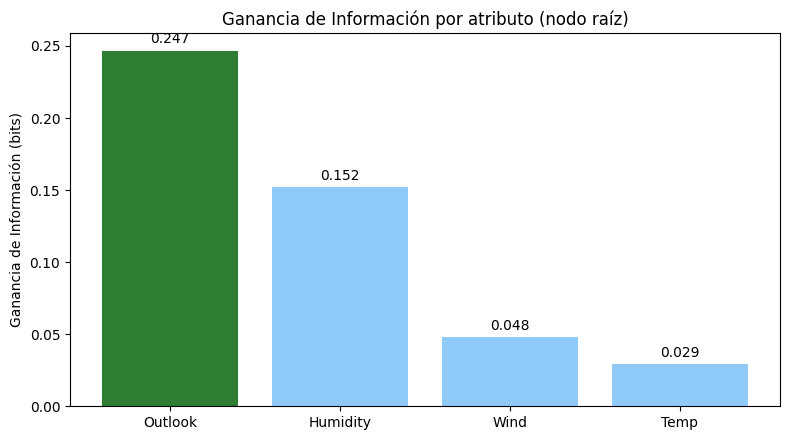

Atributo raíz elegido: 'Outlook' (mayor ganancia)


In [ ]:
# ------- Gráfico 1: Ganancia de Información en el nodo raíz -------
gains_root = {a: info_gain(df_id3, a, target) for a in attrs}
gains_root = dict(sorted(gains_root.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(8, 4.5))
barras = plt.bar(gains_root.keys(), gains_root.values(),
                 color=["#2e7d32" if i == 0 else "#90caf9" for i in range(len(gains_root))])
plt.title("Ganancia de Información por atributo (nodo raíz)")
plt.ylabel("Ganancia de Información (bits)")
for b, v in zip(barras, gains_root.values()):
    plt.text(b.get_x() + b.get_width()/2, v + 0.005, f"{v:.3f}", ha="center", fontsize=10)
plt.tight_layout(); plt.show()

print(f"Atributo raíz elegido: '{next(iter(gains_root))}' (mayor ganancia)")


### 6.2 Árbol de decisión dibujado (Graphviz)
Representación gráfica del árbol: **rectángulos azules** = decisiones (atributos),
**óvalos verdes/rojos** = hojas (Yes/No). Mucho más legible que el texto.


In [ ]:
# ------- Gráfico 2: Árbol con Graphviz -------
# graphviz viene preinstalado en Colab. Si falla, se muestra el árbol en texto.
try:
    from graphviz import Digraph

    def dict_to_graphviz(tree, target="PlayTennis"):
        dot = Digraph(); dot.attr("node", fontname="Helvetica")
        c = [0]
        pos = {"yes", "si", "sí", "e", "edible", "comestible"}
        def add(node, parent=None, edge=None):
            nid = str(c[0]); c[0] += 1
            if isinstance(node, dict):
                attr = next(iter(node))
                dot.node(nid, attr, shape="box", style="rounded,filled", fillcolor="#bbdefb")
                if parent is not None: dot.edge(parent, nid, label=str(edge))
                for val, sub in node[attr].items():
                    add(sub, nid, val)
            else:
                color = "#a5d6a7" if str(node).strip().lower() in pos else "#ef9a9a"
                dot.node(nid, f"{target}\n= {node}", shape="ellipse",
                         style="filled", fillcolor=color)
                if parent is not None: dot.edge(parent, nid, label=str(edge))
        add(tree)
        return dot

    g = dict_to_graphviz(arbol_id3, target)
    g  # se renderiza inline en Colab/Jupyter
except Exception as e:
    print("Graphviz no disponible, se muestra en texto:", e)
    print_tree(arbol_id3)


## 7. Aplicación con **datos reales**: Mushroom (UCI)

ID3 necesita datos **categóricos**, por lo que usamos el dataset real **Mushroom** del repositorio
UCI (vía OpenML): **8.124 hongos** descritos por **22 atributos categóricos** (olor, color del
sombrero, tipo de anillo, etc.) para predecir si un hongo es **comestible (`e`)** o **venenoso (`p`)**.

> Es un caso ideal para ID3: todos los atributos son nominales y la clase es binaria categórica.


In [ ]:
# ------- Carga del dataset real Mushroom (OpenML / UCI) -------
from sklearn.datasets import fetch_openml

mush = fetch_openml("mushroom", version=1, as_frame=True)
df_m = mush.frame.copy()
df_m = df_m.astype(str)                         # asegurar categórico (string)
target_m = "class"                              # e = comestible, p = venenoso

print("Forma del dataset:", df_m.shape)
print("Distribución de clases:")
print(df_m[target_m].value_counts())
df_m.head()


Forma del dataset: (8124, 23)
Distribución de clases:
class
e    4208
p    3916
Name: count, dtype: int64


,cap-shape,cap-surface,cap-color,bruises%3F,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,class
0,x,s,n,t,p,f,c,n,k,e,...,w,w,p,w,o,p,k,s,u,p
1,x,s,y,t,a,f,c,b,k,e,...,w,w,p,w,o,p,n,n,g,e
2,b,s,w,t,l,f,c,b,n,e,...,w,w,p,w,o,p,n,n,m,e
3,x,y,w,t,p,f,c,n,n,e,...,w,w,p,w,o,p,k,s,u,p
4,x,s,g,f,n,f,w,b,k,t,...,w,w,p,w,o,e,n,a,g,e


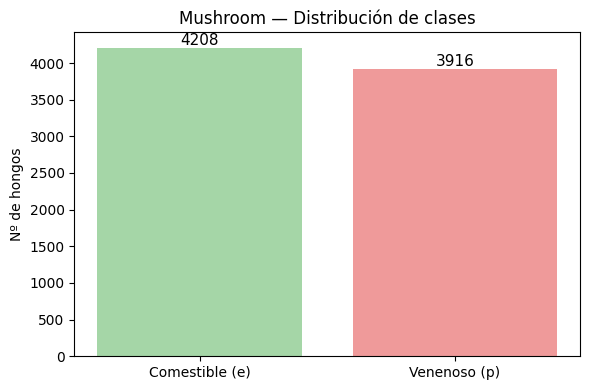

In [ ]:
# ------- Gráfico 3: Distribución de clases -------
conteo = df_m[target_m].value_counts().rename({"e": "Comestible (e)", "p": "Venenoso (p)"})
plt.figure(figsize=(6, 4))
plt.bar(conteo.index, conteo.values, color=["#a5d6a7", "#ef9a9a"])
for i, v in enumerate(conteo.values):
    plt.text(i, v + 40, str(v), ha="center", fontsize=11)
plt.title("Mushroom — Distribución de clases"); plt.ylabel("Nº de hongos")
plt.tight_layout(); plt.show()


In [ ]:
# ------- Entrenar ID3 sobre datos reales (con max_depth para un árbol interpretable) -------
from sklearn.model_selection import train_test_split

feat_m = [c for c in df_m.columns if c != target_m]
train_m, test_m = train_test_split(df_m, test_size=0.3, random_state=42, stratify=df_m[target_m])

print(f"Entropía inicial: {entropy(train_m[target_m].tolist()):.3f}\n")
print("Ganancias en el nodo raíz (por nivel):")
arbol_m = id3(train_m, target_m, feat_m, max_depth=3, verbose=True)


Entropía inicial: 0.999

Ganancias en el nodo raíz (por nivel):
[Nivel 0] cap-shape=0.047, cap-surface=0.027, cap-color=0.035, bruises%3F=0.184, odor=0.903, gill-attachment=0.016, gill-spacing=0.105, gill-size=0.224, gill-color=0.414, stalk-shape=0.008, stalk-root=0.136, stalk-surface-above-ring=0.284, stalk-surface-below-ring=0.268, stalk-color-above-ring=0.253, stalk-color-below-ring=0.244, veil-type=0.000, veil-color=0.025, ring-number=0.037, ring-type=0.313, spore-print-color=0.482, population=0.207, habitat=0.150  -> elige 'odor'
  [Nivel 1] cap-shape=0.043, cap-surface=0.017, cap-color=0.098, bruises%3F=0.001, gill-attachment=0.003, gill-spacing=0.007, gill-size=0.021, gill-color=0.092, stalk-shape=0.064, stalk-root=0.024, stalk-surface-above-ring=0.024, stalk-surface-below-ring=0.052, stalk-color-above-ring=0.036, stalk-color-below-ring=0.061, veil-type=0.000, veil-color=0.013, ring-number=0.027, ring-type=0.001, spore-print-color=0.153, population=0.047, habitat=0.065  -> elige

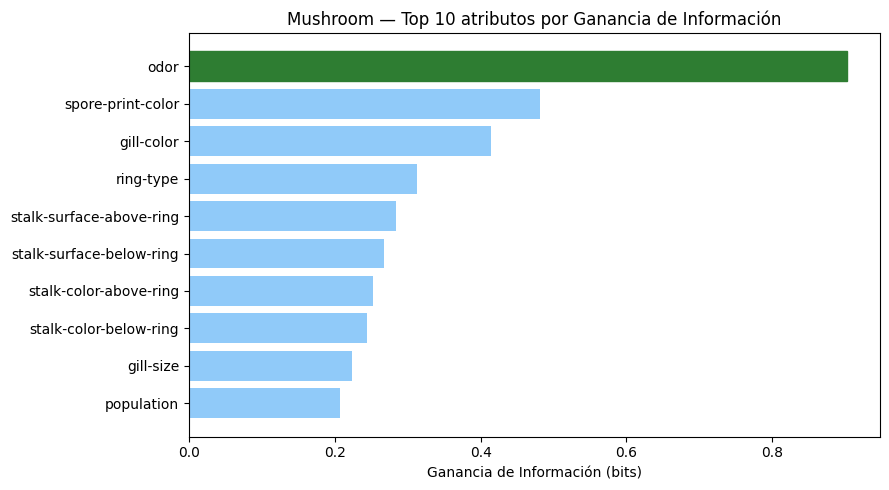

Atributo raíz: 'odor'  (el olor suele separar casi perfecto)


In [ ]:
# ------- Ganancia de Información: top-10 atributos reales (nodo raíz) -------
gains_m = {a: info_gain(train_m, a, target_m) for a in feat_m}
gains_m = dict(sorted(gains_m.items(), key=lambda x: x[1], reverse=True)[:10])

plt.figure(figsize=(9, 5))
barras = plt.barh(list(gains_m.keys())[::-1], list(gains_m.values())[::-1], color="#90caf9")
barras[-1].set_color("#2e7d32")   # el de mayor ganancia (arriba)
plt.title("Mushroom — Top 10 atributos por Ganancia de Información")
plt.xlabel("Ganancia de Información (bits)")
plt.tight_layout(); plt.show()

print(f"Atributo raíz: '{next(iter(gains_m))}'  (el olor suele separar casi perfecto)")


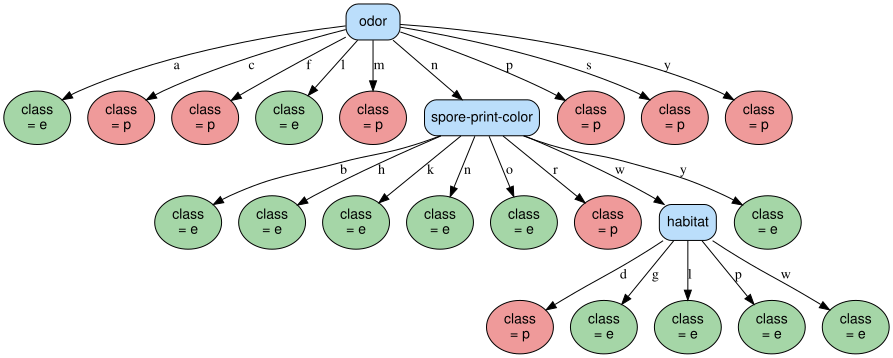


Exactitud (accuracy) en test: 99.590%  (árbol de profundidad máx. 3)


In [ ]:
# ------- Árbol real dibujado + evaluación en test -------
# 1) Visualización
try:
    g_m = dict_to_graphviz(arbol_m, target_m)
    display(g_m)
except Exception as e:
    print("Graphviz no disponible:", e); print_tree(arbol_m, target=target_m)

# 2) Exactitud (accuracy) sobre el conjunto de prueba
default_cls = train_m[target_m].mode()[0]
y_true = test_m[target_m].tolist()
y_pred = [predict(arbol_m, row, default=default_cls) for _, row in test_m.iterrows()]
acc = sum(t == p for t, p in zip(y_true, y_pred)) / len(y_true)
print(f"\nExactitud (accuracy) en test: {acc:.3%}  (árbol de profundidad máx. 3)")


## Conclusión
- Con **PlayTennis** vimos el mecanismo interno de ID3 (entropía → ganancia de información → división multi-vía).
- Con **Mushroom (datos reales)** confirmamos que ID3 funciona sobre datos categóricos reales: el
  atributo **olor (`odor`)** concentra casi toda la información y permite clasificar hongos
  comestibles/venenosos con altísima exactitud usando muy pocos niveles.
- Los **gráficos** (barras de ganancia + árbol Graphviz) hacen transparente *por qué* el modelo decide.

### Referencia
Quinlan, J. R. (1986). Induction of decision trees. *Machine Learning, 1*(1), 81–106.
